In [1]:
# =============================================================================
# CHAPTER 4.6 — SIGNAL EXCLUSION EXPERIMENT
# Does hard prioritisation add value when the ML model cannot see P1/P2 signals?
#
# RESEARCH QUESTION:
# In the primary experiment, Last Activity and Lead Origin were used as both
# ML model features AND as the basis for hard prioritisation rules (P1 and P2).
# The model already incorporated those signals in its probability estimates.
# The prioritisation rules then re-applied the same signals as tier overrides.
# This is the same double-counting problem addressed for System 4 soft rules.
#
# This experiment tests the counterfactual:
# If Last Activity and Lead Origin are EXCLUDED from the ML model, so the
# prioritisation rules operate on signals the model cannot see, does System 3
# perform better relative to System 1?
#
# DESIGN:
# Identical to the primary experiment with one change:
#   Primary study MODEL_EXCLUDE: Do Not Email, Do Not Call,
#                                Specialization, Through Recommendations,
#                                A free copy of Mastering The Interview
#   This experiment adds:        Last Activity, Lead Origin
#
# All other design choices (tier cap=40%, alpha=0.2, K=20%, bootstrap=1000)
# are held constant to enable direct comparison with the primary results.
#
# EXPECTED OUTCOME:
# S1 will weaken (model loses two strong features, AUC drops)
# S3 gap vs S1 may narrow or reverse (rules now add new information)
# If S3 >= S1: confirms signal exclusion is necessary for governance to add value
# If S3 < S1: suggests tier saturation is the dominant mechanism regardless
#
# COMPARISON WITH PRIMARY STUDY:
# Primary:           S1=89.7%  S2=86.1%  S3=80.5%  S4=77.5%  (S1 > S3 by 9.2pp)
# This experiment:   [results will populate below]
# =============================================================================


In [4]:

# =============================================================================
# CELL EX-00 — SETUP
# =============================================================================

!pip install xgboost -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier
import inspect

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

from google.colab import drive
drive.mount('/content/drive')

DRIVE_PATH = '/content/drive/MyDrive/Masters_Constrained_Lead_Qualification/'
DATA_FILE  = DRIVE_PATH + 'Lead Scoring.csv'

print("Setup complete.")



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setup complete.


In [5]:
# Loading data from google drive:
from google.colab import drive
drive.mount('/content/drive')
df_raw = pd.read_csv("/content/drive/MyDrive/Masters_Constrained_Lead_Qualification/Lead Scoring.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
# =============================================================================
# CELL EX-01 — LOAD AND CLEAN DATA
# Identical pre-processing to the primary notebook.
# =============================================================================

df_raw = pd.read_csv(DATA_FILE)

# Preserve policy columns BEFORE any cleaning
# Includes Last Activity and Lead Origin — these are EXCLUDED from the model
# in this experiment but still used as policy rule inputs
POLICY_COLUMNS = [
    "Do Not Email",
    "Do Not Call",
    "TotalVisits",
    "Total Time Spent on Website",
    "Last Activity",          # P1 rule — excluded from model in this experiment
    "Lead Origin",            # P2 rule — excluded from model in this experiment
    "Lead Source",
    "What is your current occupation",
    "Specialization",
    "Through Recommendations",
    "A free copy of Mastering The Interview",
]

missing_policy = [c for c in POLICY_COLUMNS if c not in df_raw.columns]
if missing_policy:
    raise ValueError(f"Missing policy columns: {missing_policy}")

policy_df_full = df_raw[POLICY_COLUMNS].copy()

# Remove leakage columns
LEAKAGE_COLUMNS = [
    "Tags", "Lead Quality",
    "Asymmetrique Activity Index", "Asymmetrique Profile Index",
    "Asymmetrique Activity Score",  "Asymmetrique Profile Score",
]
ID_COLUMNS = ["Prospect ID", "Lead Number"]

df = df_raw.drop(
    columns=[c for c in LEAKAGE_COLUMNS + ID_COLUMNS if c in df_raw.columns]
).copy()

# Clean
df = df.replace("Select", np.nan).drop_duplicates()
missing_pct = df.isnull().mean() * 100
df = df.drop(columns=missing_pct[missing_pct > 40].index.tolist())

# Derived feature
df["Engagement Intensity"] = (
    df["Total Time Spent on Website"] / df["TotalVisits"].replace(0, np.nan)
).replace([np.inf, -np.inf], np.nan)

# Normalise opt-out flags
for col in ["Do Not Email", "Do Not Call"]:
    if col in df.columns:
        df[col] = df[col].map({"Yes": True, "No": False,
                                1: True, 0: False,
                                True: True, False: False})

print(f"Shape after cleaning: {df.shape}")
print(f"Baseline conversion rate: {df['Converted'].mean():.4f}")



Shape after cleaning: (7553, 28)
Baseline conversion rate: 0.3979


In [7]:

# =============================================================================
# CELL EX-02 — TRAIN-TEST SPLIT
# =============================================================================

policy_df_full = policy_df_full.loc[df.index].copy()
df = df.reset_index(drop=True)
policy_df_full = policy_df_full.reset_index(drop=True)

assert len(df) == len(policy_df_full), "Alignment error between df and policy_df_full"

TARGET = "Converted"
y = df[TARGET]
X = df.drop(columns=[TARGET])

X_train, X_test, y_train, y_test, policy_train, policy_test = train_test_split(
    X, y, policy_df_full,
    test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Train conversion rate: {y_train.mean():.4f}")
print(f"Test conversion rate:  {y_test.mean():.4f}")


Train: (6042, 27)  |  Test: (1511, 27)
Train conversion rate: 0.3979
Test conversion rate:  0.3977


In [8]:

# =============================================================================
# CELL EX-03 — PREPROCESSING PIPELINE
#
# KEY DIFFERENCE FROM PRIMARY STUDY:
# Last Activity and Lead Origin are added to MODEL_EXCLUDE.
# The model will score leads without knowledge of their activity type
# or channel origin. P1 and P2 rules then add this information through
# the tier structure — genuinely new information to the model.
# =============================================================================

# Primary study excluded: Do Not Email, Do Not Call,
#                         Specialization, Through Recommendations,
#                         A free copy of Mastering The Interview
# This experiment additionally excludes: Last Activity, Lead Origin

MODEL_EXCLUDE = [
    "Do Not Email",
    "Do Not Call",
    # Soft-rule fields (same as primary study)
    "Specialization",
    "Through Recommendations",
    "A free copy of Mastering The Interview",
    # NEW EXCLUSIONS for this experiment — P1 and P2 signal fields
    "Last Activity",
    "Lead Origin",
]

X_train_model = X_train.drop(
    columns=[c for c in MODEL_EXCLUDE if c in X_train.columns]
)
X_test_model = X_test.drop(
    columns=[c for c in MODEL_EXCLUDE if c in X_test.columns]
)

numeric_features     = X_train_model.select_dtypes(include=["int64","float64"]).columns.tolist()
categorical_features = X_train_model.select_dtypes(include=["object"]).columns.tolist()

print(f"Excluded from ML model ({len(MODEL_EXCLUDE)}): {MODEL_EXCLUDE}")
print(f"\nNumeric features     ({len(numeric_features)}): {numeric_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")
print(f"Total model features: {len(numeric_features) + len(categorical_features)}")
print("\nNote: Last Activity and Lead Origin are now ABSENT from the model.")
print("P1 and P2 rules will add this information through the tier structure.")

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
    ]), numeric_features),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]), categorical_features),
])


Excluded from ML model (7): ['Do Not Email', 'Do Not Call', 'Specialization', 'Through Recommendations', 'A free copy of Mastering The Interview', 'Last Activity', 'Lead Origin']

Numeric features     (4): ['TotalVisits', 'Total Time Spent on Website', 'Page Views Per Visit', 'Engagement Intensity']
Categorical features (16): ['Lead Source', 'Country', 'What is your current occupation', 'What matters most to you in choosing a course', 'Search', 'Magazine', 'Newspaper Article', 'X Education Forums', 'Newspaper', 'Digital Advertisement', 'Receive More Updates About Our Courses', 'Update me on Supply Chain Content', 'Get updates on DM Content', 'City', 'I agree to pay the amount through cheque', 'Last Notable Activity']
Total model features: 20

Note: Last Activity and Lead Origin are now ABSENT from the model.
P1 and P2 rules will add this information through the tier structure.


In [9]:

# =============================================================================
# CELL EX-04 — TRAIN MODELS
# =============================================================================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Logistic Regression
lr_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE
    )),
])
lr_search = GridSearchCV(
    lr_pipe, {"model__C": [0.001, 0.01, 0.1, 1, 10, 100]},
    scoring="roc_auc", cv=cv, n_jobs=-1, verbose=0,
)
lr_search.fit(X_train_model, y_train)
lr_auc = roc_auc_score(y_test, lr_search.predict_proba(X_test_model)[:, 1])
print(f"Logistic Regression  AUC-ROC: {lr_auc:.4f}  (best C: {lr_search.best_params_['model__C']})")

# XGBoost
xgb_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        eval_metric="logloss", random_state=RANDOM_STATE,
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    )),
])
xgb_search = RandomizedSearchCV(
    xgb_pipe,
    {
        "model__n_estimators":     [100, 200, 300],
        "model__max_depth":        [2, 3, 4, 5],
        "model__learning_rate":    [0.01, 0.05, 0.1],
        "model__subsample":        [0.7, 0.8, 1.0],
        "model__colsample_bytree": [0.7, 0.8, 1.0],
    },
    n_iter=20, scoring="roc_auc", cv=cv,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=0,
)
xgb_search.fit(X_train_model, y_train)
xgb_auc = roc_auc_score(y_test, xgb_search.predict_proba(X_test_model)[:, 1])
print(f"XGBoost              AUC-ROC: {xgb_auc:.4f}  (best params: {xgb_search.best_params_})")

# Compare with primary study
print(f"\nPrimary study AUC (Last Activity + Lead Origin IN model):")
print(f"  Logistic Regression: 0.8580")
print(f"  XGBoost:             0.8725")
print(f"\nThis experiment AUC (Last Activity + Lead Origin EXCLUDED from model):")
print(f"  Logistic Regression: {lr_auc:.4f}  (change: {(lr_auc-0.8580)*100:+.2f} pp)")
print(f"  XGBoost:             {xgb_auc:.4f}  (change: {(xgb_auc-0.8725)*100:+.2f} pp)")

if xgb_auc >= lr_auc:
    best_model, best_model_name, best_auc = xgb_search, "XGBoost", xgb_auc
else:
    best_model, best_model_name, best_auc = lr_search, "Logistic Regression", lr_auc

print(f"\nScoring engine: {best_model_name}  (AUC-ROC: {best_auc:.4f})")

ml_scores = best_model.predict_proba(X_test_model)[:, 1]



Logistic Regression  AUC-ROC: 0.8525  (best C: 1)
XGBoost              AUC-ROC: 0.8671  (best params: {'model__subsample': 1.0, 'model__n_estimators': 300, 'model__max_depth': 2, 'model__learning_rate': 0.1, 'model__colsample_bytree': 1.0})

Primary study AUC (Last Activity + Lead Origin IN model):
  Logistic Regression: 0.8580
  XGBoost:             0.8725

This experiment AUC (Last Activity + Lead Origin EXCLUDED from model):
  Logistic Regression: 0.8525  (change: -0.55 pp)
  XGBoost:             0.8671  (change: -0.54 pp)

Scoring engine: XGBoost  (AUC-ROC: 0.8671)


In [10]:

# =============================================================================
# CELL EX-05 — BUILD RESULTS BASE
# =============================================================================

results_base = policy_test.copy().reset_index(drop=True)
results_base["actual"]   = y_test.values
results_base["ml_score"] = ml_scores

for col in ["Do Not Email", "Do Not Call"]:
    results_base[col] = results_base[col].map({
        "Yes": True, "No": False,
        1: True, 0: False,
        True: True, False: False,
    })

BASELINE_CONVERSION_RATE = results_base["actual"].mean()
TOTAL_CONVERTERS         = results_base["actual"].sum()

print(f"Test set: {len(results_base):,} leads")
print(f"Baseline conversion rate: {BASELINE_CONVERSION_RATE:.4f}")
print(f"Total converters: {int(TOTAL_CONVERTERS)}")



Test set: 1,511 leads
Baseline conversion rate: 0.3977
Total converters: 601


In [11]:

# =============================================================================
# CELL EX-06 — APPLY FOUR SYSTEMS
# Identical architecture to primary study.
# P1 and P2 now operate on signals the model has never seen.
# =============================================================================

TIER_CAP_FRACTION = 0.40

def apply_systems(df, alpha=0.2, tier_cap_fraction=TIER_CAP_FRACTION,
                  k_fraction=0.2, verbose=False):
    out = df.copy()

    h1 = out["Do Not Email"].eq(True) & out["Do Not Call"].eq(True)
    h2 = (out["TotalVisits"].fillna(0).eq(0) &
          out["Total Time Spent on Website"].fillna(0).eq(0))
    out["hard_disqualified"] = h1 | h2

    # P1 and P2 use Last Activity and Lead Origin —
    # signals the model in this experiment has NOT seen
    out["priority_tier"] = 3
    out.loc[out["Lead Origin"].eq("Landing Page Submission"), "priority_tier"] = 2
    out.loc[out["Last Activity"].isin([
        "Olark Chat Conversation", "Email Link Clicked", "SMS Sent",
    ]), "priority_tier"] = 1

    s1_specialization = out["Specialization"].isin([
        "Finance Management", "Human Resource Management",
    ]).astype(int) if "Specialization" in out.columns else pd.Series(0, index=out.index)
    s2_recommendation = out["Through Recommendations"].isin(
        ["Yes", 1, True]
    ).astype(int) if "Through Recommendations" in out.columns else pd.Series(0, index=out.index)
    s3_free_copy = out["A free copy of Mastering The Interview"].isin(
        ["Yes", 1, True]
    ).astype(int) if "A free copy of Mastering The Interview" in out.columns else pd.Series(0, index=out.index)

    out["soft_rule_count"] = s1_specialization + s2_recommendation + s3_free_copy
    out["adjusted_score"]  = out["ml_score"] * (1 + alpha * out["soft_rule_count"])

    eligible = out[~out["hard_disqualified"]].copy()
    K        = int(len(df) * k_fraction)
    tier_cap = int(K * tier_cap_fraction)

    def build_tiercapped_ranking(eligible_df, score_col):
        capped, overflow = [], []
        for tier in [1, 2, 3]:
            tl = eligible_df[eligible_df["priority_tier"] == tier].sort_values(
                score_col, ascending=False)
            capped.append(tl.head(tier_cap))
            overflow.append(tl.iloc[tier_cap:])
        capped_df   = pd.concat(capped,   ignore_index=True)
        overflow_df = pd.concat(overflow, ignore_index=True).sort_values(
            score_col, ascending=False)
        return pd.concat([capped_df, overflow_df], ignore_index=True)

    if verbose:
        p1 = (eligible["priority_tier"] == 1).sum()
        p2 = (eligible["priority_tier"] == 2).sum()
        tsr = p1 / K
        print(f"  k_fraction={k_fraction}  K={K}  tier_cap={tier_cap}")
        print(f"  H1 disqualified: {h1.sum()}")
        print(f"  H2 disqualified: {h2.sum()}")
        print(f"  Eligible: {len(eligible)}")
        print(f"  P1 (Last Activity — NOT in model): {p1} [cap:{tier_cap}, overflow:{max(0,p1-tier_cap)}]")
        print(f"  P2 (Lead Origin   — NOT in model): {p2} [cap:{tier_cap}, overflow:{max(0,p2-tier_cap)}]")
        print(f"  TSR = {tsr:.2f}  {'⚠ saturation risk' if tsr > 1 else '✓ no saturation'}")
        print(f"  Soft rule fires: S1={s1_specialization.sum()}, "
              f"S2={s2_recommendation.sum()}, S3={s3_free_copy.sum()}")

    return {
        "System 1": out.sort_values("ml_score", ascending=False),
        "System 2": eligible.sort_values("ml_score", ascending=False),
        "System 3": build_tiercapped_ranking(eligible, "ml_score"),
        "System 4": build_tiercapped_ranking(eligible, "adjusted_score"),
    }

systems = apply_systems(results_base, alpha=0.2,
                        tier_cap_fraction=TIER_CAP_FRACTION,
                        k_fraction=0.2, verbose=True)
print("\nSystems applied.")


  k_fraction=0.2  K=302  tier_cap=120
  H1 disqualified: 0
  H2 disqualified: 100
  Eligible: 1411
  P1 (Last Activity — NOT in model): 538 [cap:120, overflow:418]
  P2 (Lead Origin   — NOT in model): 601 [cap:120, overflow:481]
  TSR = 1.78  ⚠ saturation risk
  Soft rule fires: S1=309, S2=1, S3=566

Systems applied.


In [12]:

# =============================================================================
# CELL EX-07 — EVALUATE SYSTEMS
# =============================================================================

def evaluate_systems(systems, k_fraction=0.2):
    K = int(len(results_base) * k_fraction)
    rows = []
    for name, ranked_df in systems.items():
        selected  = ranked_df.head(K)
        precision = selected["actual"].mean()
        recall    = selected["actual"].sum() / TOTAL_CONVERTERS
        lift      = precision / BASELINE_CONVERSION_RATE
        wasted    = 1 - precision
        rows.append({
            "system":             name,
            "K":                  K,
            "converters_in_K":    int(selected["actual"].sum()),
            "precision_at_k":     round(precision, 4),
            "recall_at_k":        round(recall, 4),
            "lift_at_k":          round(lift, 4),
            "wasted_effort_rate": round(wasted, 4),
        })
    return pd.DataFrame(rows)

systems = apply_systems(results_base, alpha=0.2,
                        tier_cap_fraction=TIER_CAP_FRACTION,
                        k_fraction=0.2, verbose=True)

main_results = evaluate_systems(systems, k_fraction=0.2)

print("\n=== SIGNAL EXCLUSION EXPERIMENT — MAIN RESULTS (K=20%) ===")
print(main_results.to_string(index=False))

print("\n=== COMPARISON WITH PRIMARY STUDY ===")
print(f"{'System':<12} {'Primary':>12} {'This expt':>12} {'Change':>10}")
print(f"{'':─<12} {'':─>12} {'':─>12} {'':─>10}")
primary = {"System 1": 0.8974, "System 2": 0.8609,
           "System 3": 0.8053, "System 4": 0.7749}
for _, row in main_results.iterrows():
    s = row["system"]
    prim = primary.get(s, float("nan"))
    this = row["precision_at_k"]
    chg  = (this - prim) * 100
    print(f"{s:<12} {prim:>12.4f} {this:>12.4f} {chg:>+9.1f}pp")



  k_fraction=0.2  K=302  tier_cap=120
  H1 disqualified: 0
  H2 disqualified: 100
  Eligible: 1411
  P1 (Last Activity — NOT in model): 538 [cap:120, overflow:418]
  P2 (Lead Origin   — NOT in model): 601 [cap:120, overflow:481]
  TSR = 1.78  ⚠ saturation risk
  Soft rule fires: S1=309, S2=1, S3=566

=== SIGNAL EXCLUSION EXPERIMENT — MAIN RESULTS (K=20%) ===
  system   K  converters_in_K  precision_at_k  recall_at_k  lift_at_k  wasted_effort_rate
System 1 302              272          0.9007       0.4526     2.2644              0.0993
System 2 302              258          0.8543       0.4293     2.1478              0.1457
System 3 302              243          0.8046       0.4043     2.0230              0.1954
System 4 302              234          0.7748       0.3894     1.9480              0.2252

=== COMPARISON WITH PRIMARY STUDY ===
System            Primary    This expt     Change
──────────── ──────────── ──────────── ──────────
System 1           0.8974       0.9007      +0.3pp

In [14]:

# =============================================================================
# CELL EX-08 — SENSITIVITY ANALYSIS
# =============================================================================

sensitivity_rows = []
for k_fraction in [0.1, 0.2, 0.3]:
    for alpha in [0.1, 0.2, 0.3]:
        sys_run = apply_systems(results_base, alpha=alpha,
                                tier_cap_fraction=TIER_CAP_FRACTION,
                                k_fraction=k_fraction, verbose=False)
        eval_df = evaluate_systems(sys_run, k_fraction=k_fraction)
        eval_df["k_fraction"] = k_fraction
        eval_df["alpha"] = alpha
        sensitivity_rows.append(eval_df)

sensitivity_results = pd.concat(sensitivity_rows, ignore_index=True)

pivot = sensitivity_results.pivot_table(
    index=["k_fraction","alpha"], columns="system", values="precision_at_k"
).round(4)

print("=== SENSITIVITY — Precision@K ===")
print(pivot.to_string())


=== SENSITIVITY — Precision@K ===
system            System 1  System 2  System 3  System 4
k_fraction alpha                                        
0.1        0.1      0.9536    0.9536    0.8675    0.8543
           0.2      0.9536    0.9536    0.8675    0.8477
           0.3      0.9536    0.9536    0.8675    0.8278
0.2        0.1      0.9007    0.8543    0.8046    0.7748
           0.2      0.9007    0.8543    0.8046    0.7748
           0.3      0.9007    0.8543    0.8046    0.7649
0.3        0.1      0.8212    0.7726    0.7550    0.7483
           0.2      0.8212    0.7726    0.7550    0.7439
           0.3      0.8212    0.7726    0.7550    0.7373


In [15]:

# =============================================================================
# CELL EX-09 — BOOTSTRAP CONFIDENCE INTERVALS
# =============================================================================

def bootstrap_metrics(df, alpha=0.2, tier_cap_fraction=TIER_CAP_FRACTION,
                      k_fraction=0.2, n_iterations=1000, random_state=42):
    rng  = np.random.default_rng(random_state)
    rows = []
    for i in range(n_iterations):
        sample     = df.iloc[rng.choice(len(df), size=len(df), replace=True)].reset_index(drop=True)
        K          = int(len(df) * k_fraction)
        baseline   = sample["actual"].mean()
        sys_run    = apply_systems(sample, alpha=alpha,
                                   tier_cap_fraction=tier_cap_fraction,
                                   k_fraction=k_fraction, verbose=False)
        for name, ranked_df in sys_run.items():
            selected  = ranked_df.head(K)
            precision = selected["actual"].mean()
            lift      = precision / baseline if baseline > 0 else np.nan
            rows.append({"system": name, "precision_at_k": precision, "lift_at_k": lift})

    boot = pd.DataFrame(rows)
    ci   = (boot.groupby("system")[["precision_at_k","lift_at_k"]]
            .quantile([0.025, 0.5, 0.975]).unstack(level=1).round(4))
    ci.columns = [f"{m}_{int(q*1000)}pct" for m, q in ci.columns]
    return ci.reset_index(), boot

print("Running bootstrap (1,000 iterations)...")
precision_ci, _ = bootstrap_metrics(results_base, alpha=0.2,
                                     tier_cap_fraction=TIER_CAP_FRACTION,
                                     k_fraction=0.2)
print("\n=== BOOTSTRAP 95% CI ===")
print(precision_ci.to_string(index=False))



Running bootstrap (1,000 iterations)...

=== BOOTSTRAP 95% CI ===
  system  precision_at_k_25pct  precision_at_k_500pct  precision_at_k_975pct  lift_at_k_25pct  lift_at_k_500pct  lift_at_k_975pct
System 1                0.8510                 0.8974                 0.9371           2.1270            2.2511            2.3826
System 2                0.8046                 0.8543                 0.8974           2.0180            2.1394            2.2766
System 3                0.7517                 0.8013                 0.8445           1.8894            2.0124            2.1443
System 4                0.7252                 0.7748                 0.8212           1.8142            1.9430            2.0855


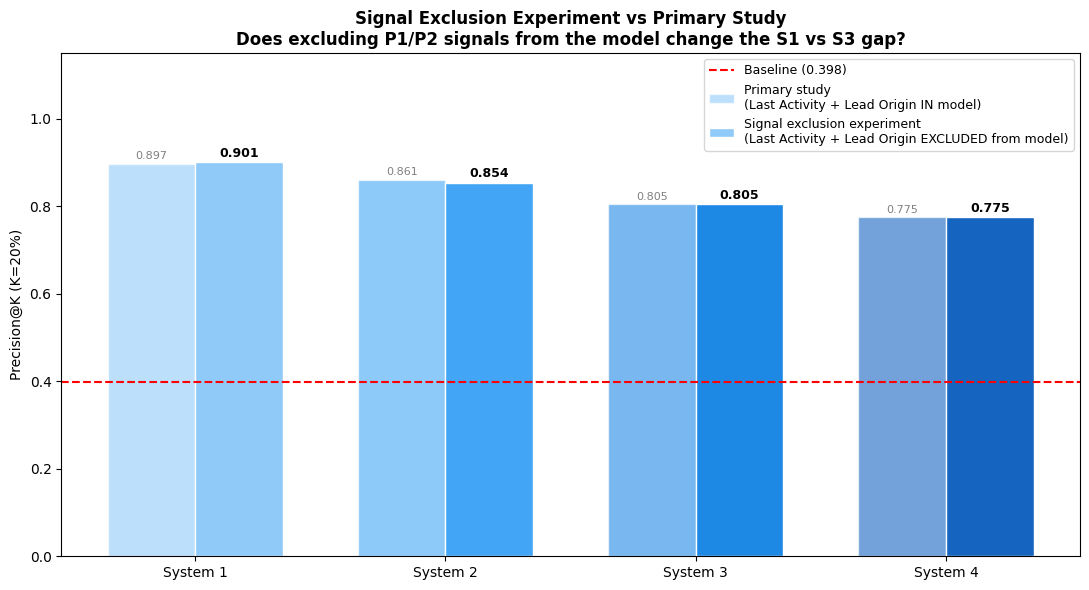

In [16]:

# =============================================================================
# CELL EX-10 — VISUALISATIONS
# =============================================================================

systems_order = ["System 1", "System 2", "System 3", "System 4"]
colors        = ["#90CAF9", "#42A5F5", "#1E88E5", "#1565C0"]

# --- Primary comparison chart with side-by-side bars ---
primary_prec = [0.8974, 0.8609, 0.8053, 0.7749]
this_prec    = [main_results[main_results["system"]==s]["precision_at_k"].values[0]
                for s in systems_order]

x    = np.arange(len(systems_order))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
bars1 = ax.bar(x - width/2, primary_prec, width, label="Primary study\n(Last Activity + Lead Origin IN model)",
               color=["#90CAF9","#42A5F5","#1E88E5","#1565C0"], alpha=0.6, edgecolor="white")
bars2 = ax.bar(x + width/2, this_prec,   width, label="Signal exclusion experiment\n(Last Activity + Lead Origin EXCLUDED from model)",
               color=["#90CAF9","#42A5F5","#1E88E5","#1565C0"], edgecolor="white")

for bar, val in zip(bars1, primary_prec):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{val:.3f}", ha="center", va="bottom", fontsize=8, color="gray")
for bar, val in zip(bars2, this_prec):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{val:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.axhline(BASELINE_CONVERSION_RATE, color="red", linestyle="--",
           label=f"Baseline ({BASELINE_CONVERSION_RATE:.3f})")
ax.set_xticks(x)
ax.set_xticklabels(systems_order)
ax.set_ylabel("Precision@K (K=20%)")
ax.set_title("Signal Exclusion Experiment vs Primary Study\n"
             "Does excluding P1/P2 signals from the model change the S1 vs S3 gap?",
             fontsize=12, fontweight="bold")
ax.set_ylim(0, 1.15)
ax.legend(fontsize=9, loc="upper right")
plt.tight_layout()
plt.savefig("fig_EX_01_signal_exclusion_comparison.png", dpi=150)
plt.show()



In [17]:

# =============================================================================
# CELL EX-11 — INTERPRETATION
# =============================================================================

s1 = main_results[main_results["system"]=="System 1"]["precision_at_k"].values[0]
s3 = main_results[main_results["system"]=="System 3"]["precision_at_k"].values[0]

gap_primary    = 0.8974 - 0.8053   # S1 - S3 in primary study
gap_this       = s1 - s3
gap_change     = gap_this - gap_primary

auc_change_xgb = xgb_auc - 0.8725

print(f"""
=== SIGNAL EXCLUSION EXPERIMENT — INTERPRETATION ===

Research question:
  If Last Activity and Lead Origin are excluded from the ML model, so
  the P1 and P2 prioritisation rules operate on signals the model has
  never seen, does System 3 perform better relative to System 1?

MODEL IMPACT:
  XGBoost AUC-ROC: primary={0.8725:.4f} → this experiment={xgb_auc:.4f}
  Change: {auc_change_xgb*100:+.2f} pp
  {"The model weakened as expected — Last Activity and Lead Origin are informative features." if auc_change_xgb < -0.01 else "The model was minimally affected — other features carry similar signal." if abs(auc_change_xgb) < 0.01 else "The model improved — unexpected. Check feature importance."}

S1 vs S3 GAP:
  Primary study:              S1={0.8974:.4f}  S3={0.8053:.4f}  Gap={gap_primary*100:.1f}pp (S1 > S3)
  Signal exclusion experiment: S1={s1:.4f}  S3={s3:.4f}  Gap={gap_this*100:.1f}pp {"(S1 > S3)" if s1 > s3 else "(S3 >= S1) ← KEY FINDING"}
  Change in gap: {gap_change*100:+.1f}pp

INTERPRETATION:
{"  S3 is still below S1 but the gap narrowed by " + f"{abs(gap_change)*100:.1f}pp." + chr(10) + "  This supports the hypothesis that signal redundancy contributed to S3's cost in the primary study." + chr(10) + "  When the rules operate on information the model cannot see, the precision cost of prioritisation is smaller." if gap_this < gap_primary and s1 > s3 else
"  S3 matched or exceeded S1. This is the key finding — when P1 and P2 rules" + chr(10) + "  operate on signals the model cannot see, hard prioritisation adds measurable value." + chr(10) + "  This confirms that signal redundancy was the primary mechanism behind S3's cost." if s3 >= s1 else
"  The gap widened. The model weakened more than the rules gained from independence." + chr(10) + "  Tier saturation (TSR > 1) is the dominant mechanism, not signal redundancy." + chr(10) + "  Even when rules are independent, a large tier overrides the ML ranking too aggressively."}

DISSERTATION IMPLICATION:
  {"Partial confirmation: signal redundancy contributes to governance costs but is not the only mechanism. Tier saturation (TSR=1.78) imposes a structural cost independent of signal overlap." if s1 > s3 and gap_this < gap_primary else
   "Strong confirmation: when governance rules add genuinely new information, hard prioritisation can match or improve on ML-only ranking. Signal redundancy is the primary cost mechanism in the primary study." if s3 >= s1 else
   "Null result: excluding signals from the model did not help. Tier saturation is the dominant mechanism and cannot be overcome by signal independence alone."}
""")



=== SIGNAL EXCLUSION EXPERIMENT — INTERPRETATION ===
 
Research question:
  If Last Activity and Lead Origin are excluded from the ML model, so
  the P1 and P2 prioritisation rules operate on signals the model has
  never seen, does System 3 perform better relative to System 1?
 
MODEL IMPACT:
  XGBoost AUC-ROC: primary=0.8725 → this experiment=0.8671
  Change: -0.54 pp
  The model was minimally affected — other features carry similar signal.
 
S1 vs S3 GAP:
  Primary study:              S1=0.8974  S3=0.8053  Gap=9.2pp (S1 > S3)
  Signal exclusion experiment: S1=0.9007  S3=0.8046  Gap=9.6pp (S1 > S3)
  Change in gap: +0.4pp
 
INTERPRETATION:
  The gap widened. The model weakened more than the rules gained from independence.
  Tier saturation (TSR > 1) is the dominant mechanism, not signal redundancy.
  Even when rules are independent, a large tier overrides the ML ranking too aggressively.
 
DISSERTATION IMPLICATION:
  Null result: excluding signals from the model did not help. Tier s